# Module 03 Lab - CNNs for Image Classification: Puppy or Bagel? 🐶🥯

Welcome to Module 03! In this lab, we will explore **Convolutional Neural Networks (CNNs)** for image classification using one of the internet's most amusing classification challenges: **Can you tell the difference between a puppy and a bagel?**

**What you'll learn:**
- CNN fundamentals: convolutional layers, pooling, and feature maps
- Building a CNN from scratch for binary image classification
- Transfer learning with pre-trained models
- Fine-tuning strategies for custom datasets

**Dataset:** Puppy or Bagel
- **Kaggle Link:** https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

### The Famous Meme That Started It All!
This dataset is inspired by Karen Zack's (@teenybiscuit) viral meme showing how curled-up puppies look remarkably similar to bagels!

In [1]:
# ============================================================
# DISPLAY THE FAMOUS PUPPY OR BAGEL MEME
# This cell shows the viral meme that inspired our dataset
# ============================================================

from IPython.display import Image, display, HTML

# Display the original "Puppy or Bagel" meme by Karen Zack
display(HTML('''
<div style="text-align: center; padding: 20px; background-color: #f5f5f5; border-radius: 10px;">
    <h3>🐶 The Famous "Puppy or Bagel?" Challenge 🥯</h3>
    <img src="https://static.boredpanda.com/blog/wp-content/uploads/2016/03/dog-food-comparison-bagel-muffin-lookalike-teenybiscuit-karen-zack__700.jpg"
         width="600" alt="Puppy or Bagel meme by Karen Zack">
    <p><i>Original meme by Karen Zack (@teenybiscuit) - Can YOU tell which is which?</i></p>
</div>
'''))

## Learning Objectives

By the end of this lab, you will be able to:

- **Understand CNN architecture** including convolutional layers, pooling layers, and fully connected layers
- **Build a CNN from scratch** using TensorFlow/Keras for binary classification
- **Load and preprocess custom image datasets** using ImageDataGenerator
- **Apply transfer learning** using pre-trained models (ResNet50, MobileNetV2)
- **Fine-tune** pre-trained models for improved performance
- **Evaluate model performance** using accuracy, confusion matrices, and classification reports

---
## 1. Setup and Installation

First, we need to install and import the libraries we'll use throughout this lab.

In [2]:
# ============================================================
# INSTALL REQUIRED LIBRARIES
# The -q flag means "quiet" - less output during installation
# ============================================================

import sys
!{sys.executable} -m pip install -q tensorflow numpy matplotlib scikit-learn kaggle pillow seaborn
print("✅ Packages checked/installed")


You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
✅ Packages checked/installed


In [3]:
# ============================================================
# IMPORT ALL NECESSARY LIBRARIES
# Each library serves a specific purpose in our ML pipeline
# ============================================================

# TensorFlow/Keras - Our main deep learning framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# Pre-trained models for transfer learning
from tensorflow.keras.applications import ResNet50, VGG16, MobileNetV2

# For loading images and applying data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# NumPy - For numerical operations on arrays
import numpy as np

# Matplotlib - For plotting graphs and displaying images
import matplotlib.pyplot as plt

# Scikit-learn - For evaluation metrics (confusion matrix, etc.)
from sklearn.metrics import classification_report, confusion_matrix

# Seaborn - For prettier statistical visualizations
import seaborn as sns

# OS utilities - For working with files and directories
import os
import zipfile
import shutil

# Print version information and check for GPU availability
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Detect if we're running in Google Colab
try:
    import google.colab
    IN_COLAB = True
    print("✅ Running in Google Colab")
except:
    IN_COLAB = False
    print("💻 Running locally")

TensorFlow version: 2.19.0
GPU Available: []
💻 Running locally


---
## 2. Download and Prepare the Dataset

## 🌟 FOR GOOGLE COLAB FREE USERS 🌟

**Important Setup Steps:**
1. Go to **Runtime → Change runtime type → GPU** (makes training MUCH faster!)
2. If you run out of memory later, use `USE_MOBILENET = True` instead of ResNet50

---

### Option A: Download via Kaggle API (Recommended)

**How to get your Kaggle API key:**
1. Go to [kaggle.com](https://www.kaggle.com) → Click your profile icon → **Settings**
2. Scroll to **API** section → Click **"Create New Token"**
3. This downloads a `kaggle.json` file - upload it when prompted below

In [4]:
# ============================================================
# SETUP KAGGLE API CREDENTIALS
# This allows us to download datasets directly from Kaggle
# ============================================================

if IN_COLAB:
    from google.colab import files

    print("📤 Please upload your kaggle.json file:")
    print("   (Get it from: kaggle.com → Profile → Settings → API → Create New Token)\n")

    # This will prompt you to upload a file
    uploaded = files.upload()

    # Move the kaggle.json to the correct location
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json  # Set proper permissions

    print("\n✅ Kaggle credentials configured!")
else:
    print("Not in Colab - make sure kaggle.json is in ~/.kaggle/")

Not in Colab - make sure kaggle.json is in ~/.kaggle/


In [5]:
# ============================================================
# DOWNLOAD THE DATASET FROM KAGGLE
# This cell also supports running locally without Kaggle credentials
# ============================================================

import os
import json
import zipfile
import subprocess
from pathlib import Path

DATASET_SLUG = "returnofsputnik/puppy-or-bagel"
ZIP_FILE = "puppy-or-bagel.zip"
RAW_DATASET_DIR = "puppy-or-bagel"

def kaggle_credentials_ready():
    kaggle_json = Path.home() / ".kaggle" / "kaggle.json"
    if kaggle_json.exists():
        try:
            cfg = json.loads(kaggle_json.read_text())
            return bool(cfg.get("username")) and bool(cfg.get("key"))
        except Exception:
            return False
    return bool(os.environ.get("KAGGLE_USERNAME")) and bool(os.environ.get("KAGGLE_KEY"))

if not os.path.isdir(RAW_DATASET_DIR):
    if not os.path.isfile(ZIP_FILE) and kaggle_credentials_ready():
        print("I am downloading the dataset from Kaggle.")
        try:
            result = subprocess.run(
                ["kaggle", "datasets", "download", "-d", DATASET_SLUG],
                capture_output=True,
                text=True
            )
        except FileNotFoundError:
            print("I could not find the kaggle command.")
            result = None
        if result is None or result.returncode != 0:
            print("I could not download from Kaggle in this run.")
            if result is not None:
                print(result.stderr.strip())

    if os.path.isfile(ZIP_FILE):
        print("I am extracting the dataset zip.")
        with zipfile.ZipFile(ZIP_FILE, "r") as z:
            z.extractall(RAW_DATASET_DIR)
        print("I extracted the dataset.")
    else:
        print("I did not find the zip file.")
        print("I will use the manual download option below.")
else:
    print("I found the extracted dataset folder.")

RAW_DATASET_PATH = RAW_DATASET_DIR

if os.path.isdir(RAW_DATASET_DIR):
    items = [x for x in os.listdir(RAW_DATASET_DIR) if not x.startswith(".")]
    subdirs = [x for x in items if os.path.isdir(os.path.join(RAW_DATASET_DIR, x))]
    images = [x for x in items if x.lower().endswith((".png", ".jpg", ".jpeg"))]

    if len(images) == 0 and len(subdirs) == 1:
        RAW_DATASET_PATH = os.path.join(RAW_DATASET_DIR, subdirs[0])

print("I will use this raw dataset path:", RAW_DATASET_PATH)

I found the extracted dataset folder.
I will use this raw dataset path: puppy-or-bagel


### Option B: Manual Download (If Kaggle API doesn't work)

1. Visit: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel
2. Click **"Download"** (requires free Kaggle account)
3. In Colab: Click 📁 folder icon on left → Upload the zip file
4. Uncomment and run the cell below

In [6]:
# ============================================================
# OPTION B: MANUAL UPLOAD (Only if Kaggle API fails)
# This is safe to run even if the zip is not present
# ============================================================

import os
import zipfile

ZIP_FILE = "puppy-or-bagel.zip"
RAW_DATASET_DIR = "puppy-or-bagel"

if os.path.isfile(ZIP_FILE) and not os.path.isdir(RAW_DATASET_DIR):
    with zipfile.ZipFile(ZIP_FILE, "r") as z:
        z.extractall(RAW_DATASET_DIR)
    print("I extracted the dataset.")
else:
    print("I did not need to extract anything here.")


I did not need to extract anything here.


In [7]:
# ============================================================
# PREPARE FOLDERS FOR flow_from_directory
# If the dataset already has train val and test folders, I use them
# If it is a flat folder, I create train val and test splits
# ============================================================

import os
import shutil
import random

RAW_PATH = RAW_DATASET_PATH if "RAW_DATASET_PATH" in globals() else "puppy-or-bagel"
STRUCTURED_PATH = "puppy-or-bagel_structured"

def has_train_val_test(base_path):
    if not os.path.isdir(base_path):
        return False
    names = [n.lower() for n in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, n))]
    has_train = any(n == "train" or n.startswith("train") for n in names)
    has_test = any(n == "test" or n.startswith("test") for n in names)
    has_val = any(n in ["val", "valid", "validation"] or n.startswith("val") or n.startswith("valid") for n in names)
    return has_train and has_val and has_test

if has_train_val_test(RAW_PATH):
    DATASET_PATH = RAW_PATH
    print("I found train val and test folders already.")
else:
    if os.path.exists(STRUCTURED_PATH):
        shutil.rmtree(STRUCTURED_PATH)
    os.makedirs(STRUCTURED_PATH, exist_ok=True)

    train_dir = os.path.join(STRUCTURED_PATH, "train")
    val_dir = os.path.join(STRUCTURED_PATH, "val")
    test_dir = os.path.join(STRUCTURED_PATH, "test")

    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, "bagel"), exist_ok=True)
        os.makedirs(os.path.join(d, "puppy"), exist_ok=True)

    all_images = [
        os.path.join(RAW_PATH, f)
        for f in os.listdir(RAW_PATH)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.seed(42)
    random.shuffle(all_images)

    bagel_images = [p for p in all_images if "bagel" in os.path.basename(p).lower()]
    dog_images = [p for p in all_images if "dog" in os.path.basename(p).lower() or "puppy" in os.path.basename(p).lower()]

    train_split = 0.5
    val_split = 0.25

    def copy_split(files, train_dst, val_dst, test_dst):
        n = len(files)
        n_train = int(n * train_split)
        n_val = int(n * val_split)

        train_files = files[:n_train]
        val_files = files[n_train:n_train + n_val]
        test_files = files[n_train + n_val:]

        for f in train_files:
            shutil.copy2(f, train_dst)
        for f in val_files:
            shutil.copy2(f, val_dst)
        for f in test_files:
            shutil.copy2(f, test_dst)

        return len(train_files), len(val_files), len(test_files)

    b_train, b_val, b_test = copy_split(
        bagel_images,
        os.path.join(train_dir, "bagel"),
        os.path.join(val_dir, "bagel"),
        os.path.join(test_dir, "bagel")
    )

    p_train, p_val, p_test = copy_split(
        dog_images,
        os.path.join(train_dir, "puppy"),
        os.path.join(val_dir, "puppy"),
        os.path.join(test_dir, "puppy")
    )

    DATASET_PATH = STRUCTURED_PATH
    print("I created a structured dataset folder:", DATASET_PATH)
    print("Train bagel", b_train, "puppy", p_train)
    print("Val bagel", b_val, "puppy", p_val)
    print("Test bagel", b_test, "puppy", p_test)

I found train val and test folders already.


In [8]:
# ============================================================
# CONFIRM WHICH DATASET PATH I WILL USE
# ============================================================

print("I will use this dataset path for training:", DATASET_PATH)


I will use this dataset path for training: puppy-or-bagel


In [9]:
import os

if os.path.isdir("puppy-or-bagel"):
    print("I found the extracted dataset folder.")
elif os.path.isfile("puppy-or-bagel.zip"):
    print("I found the dataset zip file.")
else:
    print("I did not find the dataset folder or zip file.")


I found the extracted dataset folder.


In [10]:
# ============================================================
# EXPLORE THE DATASET STRUCTURE
# This helps me confirm the folder layout before training
# ============================================================

print("Dataset structure:")

for root, dirs, files_list in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level < 2:
        subindent = " " * 2 * (level + 1)
        for d in dirs[:10]:
            print(f"{subindent}{d}/")
        if len(files_list) > 0:
            print(f"{subindent}({len(files_list)} files)")


Dataset structure:
puppy-or-bagel/
  test/
  train/
  val/
  (17 files)
  test/
    puppy/
    bagel/
    (1 files)
    puppy/
    bagel/
  train/
    puppy/
    bagel/
    (1 files)
    puppy/
    bagel/
  val/
    puppy/
    bagel/
    (1 files)
    puppy/
    bagel/


In [11]:
# ============================================================
# AUTO-DETECT DATA DIRECTORIES
# This function finds train/valid/test folders automatically
# ============================================================

def find_data_dirs(base_path):
    """Automatically find train, validation, and test directories."""
    train_dir = valid_dir = test_dir = None

    # Look for directories with common naming patterns
    for item in os.listdir(base_path):
        item_path = os.path.join(base_path, item)
        if os.path.isdir(item_path):
            item_lower = item.lower()
            if 'train' in item_lower:
                train_dir = item_path
            elif 'valid' in item_lower or 'val' in item_lower:
                valid_dir = item_path
            elif 'test' in item_lower:
                test_dir = item_path

    return train_dir, valid_dir, test_dir


def count_split_images(split_dir):
    """Return class-level and total image counts for a split directory."""
    class_counts = {}
    total = 0

    if not split_dir or not os.path.isdir(split_dir):
        return class_counts, total

    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len([
                f for f in os.listdir(cls_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_counts[cls] = count
            total += count

    return class_counts, total


# Find the directories
train_dir, valid_dir, test_dir = find_data_dirs(DATASET_PATH)

# If not found at top level, check one level deeper
if train_dir is None:
    for item in os.listdir(DATASET_PATH):
        item_path = os.path.join(DATASET_PATH, item)
        if os.path.isdir(item_path):
            train_dir, valid_dir, test_dir = find_data_dirs(item_path)
            if train_dir:
                break

# Display what we found
print(f"📁 Train directory: {train_dir}")
print(f"📁 Validation directory: {valid_dir}")
print(f"📁 Test directory: {test_dir}")

# Count images in each split
train_counts, train_total = count_split_images(train_dir)
val_counts, val_total = count_split_images(valid_dir)
test_counts, test_total = count_split_images(test_dir)
dataset_total_from_splits = train_total + val_total + test_total

print("\n📊 Split summary:")
print(f"   Train: {train_total} images -> {train_counts}")
print(f"   Val:   {val_total} images -> {val_counts}")
print(f"   Test:  {test_total} images -> {test_counts}")
print(f"   Total across splits: {dataset_total_from_splits} images")
print("   This dataset is tiny, so the splits are small.")

📁 Train directory: puppy-or-bagel/train
📁 Validation directory: puppy-or-bagel/val
📁 Test directory: puppy-or-bagel/test

📊 Split summary:
   Train: 12 images -> {'bagel': 6, 'puppy': 6}
   Val:   2 images -> {'bagel': 1, 'puppy': 1}
   Test:  2 images -> {'bagel': 1, 'puppy': 1}
   Total across splits: 16 images
   This dataset is tiny, so the splits are small.


In [12]:
# ============================================================
# SET TRAINING PARAMETERS (OPTIMIZED FOR COLAB FREE)
# These settings balance training quality with resource limits
# ============================================================

if IN_COLAB:
    # Check if GPU is available
    gpu_available = len(tf.config.list_physical_devices('GPU')) > 0

    if gpu_available:
        print("✅ GPU detected! Using standard settings.")
        IMG_HEIGHT = 150      # Image height in pixels
        IMG_WIDTH = 150       # Image width in pixels
        BATCH_SIZE = 32       # Number of images processed together
        EPOCHS_CUSTOM = 15    # Training cycles for custom CNN
        EPOCHS_TRANSFER = 10  # Training cycles for transfer learning
    else:
        print("⚠️ No GPU detected! Using memory-efficient settings.")
        print("   💡 Tip: Go to Runtime → Change runtime type → GPU")
        IMG_HEIGHT = 100
        IMG_WIDTH = 100
        BATCH_SIZE = 16
        EPOCHS_CUSTOM = 8
        EPOCHS_TRANSFER = 5
else:
    # Local machine settings
    IMG_HEIGHT = 150
    IMG_WIDTH = 150
    BATCH_SIZE = 32
    EPOCHS_CUSTOM = 15
    EPOCHS_TRANSFER = 10

# Evaluation scope:
# - 'test' = evaluate only holdout test split (strict evaluation)
# - 'all'  = evaluate on train+val+test combined
EVAL_SCOPE = 'test'

# Class names (updated dynamically after generators are created)
class_names = ['bagel', 'puppy']

print(f"\n⠀ Training Configuration:")
print(f"   Image size: {IMG_HEIGHT}x{IMG_WIDTH} pixels")
print(f"   Batch size: {BATCH_SIZE} images")
print(f"   Custom CNN epochs: {EPOCHS_CUSTOM}")
print(f"   Transfer learning epochs: {EPOCHS_TRANSFER}")
print(f"   Evaluation scope: {EVAL_SCOPE}")


⠀ Training Configuration:
   Image size: 150x150 pixels
   Batch size: 32 images
   Custom CNN epochs: 15
   Transfer learning epochs: 10
   Evaluation scope: test


---
## 3. Understanding CNNs

### What makes CNNs special for images?

**Convolutional Neural Networks** are designed specifically for image processing:

1. **Preserve spatial relationships** - Nearby pixels stay connected
2. **Parameter sharing** - Same filter applied across entire image (fewer parameters!)
3. **Hierarchical features** - Learn edges → textures → shapes → objects

### Key Components:
| Layer | Purpose |
|-------|--------|
| **Conv2D** | Applies filters to detect features like edges and textures |
| **MaxPooling2D** | Reduces image size while keeping important information |
| **Flatten** | Converts 2D feature maps to 1D for classification |
| **Dense** | Fully connected layers for final decision making |
| **Dropout** | Randomly disables neurons to prevent overfitting |

### The Puppy vs Bagel Challenge:
Both puppies and bagels share visual features:
- ✓ Round, circular shapes
- ✓ Tan/brown coloring  
- ✓ Textured surfaces

Our CNN must learn the subtle differences!

---
## 4. Load and Explore the Dataset

In [13]:
# ============================================================
# CREATE DATA GENERATORS WITH AUGMENTATION
#
# Data augmentation creates variations of our images to help
# the model generalize better and prevent overfitting.
# Think of it as showing the model the same puppy from
# different angles and lighting conditions!
# ============================================================

# Training generator - includes data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels from 0-255 to 0-1
    rotation_range=20,         # Rotate images randomly up to 20°
    width_shift_range=0.2,     # Shift images horizontally
    height_shift_range=0.2,    # Shift images vertically
    shear_range=0.2,           # Apply shear transformation
    zoom_range=0.2,            # Randomly zoom in/out
    horizontal_flip=True,      # Flip images left-right
    fill_mode='nearest'        # How to fill new pixels
)

# Validation/Test generator - NO augmentation!
# We want to test on real, unmodified images
test_datagen = ImageDataGenerator(rescale=1./255)

print("✅ Data generators created!")
print("📝 Training images will be augmented (rotated, flipped, etc.)")
print("📝 Validation/Test images will only be normalized")

✅ Data generators created!
📝 Training images will be augmented (rotated, flipped, etc.)
📝 Validation/Test images will only be normalized


In [14]:
# ============================================================
# LOAD IMAGES FROM DIRECTORIES
# ============================================================

def build_all_eval_dir(base_path, out_name="_all_eval", split_names=("train", "val", "test")):
    out_dir = os.path.join(base_path, out_name)

    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    os.makedirs(out_dir, exist_ok=True)

    copied = 0
    for split in split_names:
        split_dir = os.path.join(base_path, split)
        if not os.path.isdir(split_dir):
            continue

        for cls in sorted(os.listdir(split_dir)):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue

            out_cls_dir = os.path.join(out_dir, cls)
            os.makedirs(out_cls_dir, exist_ok=True)

            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    src = os.path.join(cls_dir, fname)
                    dst = os.path.join(out_cls_dir, f"{split}_{fname}")
                    shutil.copy2(src, dst)
                    copied += 1

    return out_dir, copied


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

if valid_dir:
    validation_generator = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
else:
    validation_generator = None
    print("No validation directory found")

if test_dir:
    test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
else:
    test_generator = validation_generator
    print("Using validation data for testing")

all_eval_generator = None
all_eval_dir = None
all_eval_count = 0

if EVAL_SCOPE.lower() == "all":
    all_eval_dir, all_eval_count = build_all_eval_dir(DATASET_PATH)
    all_eval_generator = test_datagen.flow_from_directory(
        all_eval_dir,
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

class_names = sorted(train_generator.class_indices, key=train_generator.class_indices.get)

eval_generator_custom = test_generator
eval_scope_custom = "test split"

if EVAL_SCOPE.lower() == "all" and all_eval_generator is not None:
    eval_generator_custom = all_eval_generator
    eval_scope_custom = "all images (train+val+test)"

print("Class mapping:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Val samples:", validation_generator.samples if validation_generator else 0)
print("Test samples:", test_generator.samples if test_generator else 0)

if all_eval_generator is not None:
    print("All merged samples:", all_eval_generator.samples, "copied:", all_eval_count)

print("Custom CNN evaluation scope:", eval_scope_custom, "samples:", eval_generator_custom.samples)


Found 12 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Class mapping: {'bagel': 0, 'puppy': 1}
Train samples: 12
Val samples: 2
Test samples: 2
Custom CNN evaluation scope: test split samples: 2


/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/3403330712.py:27: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/3403330712.py:27: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


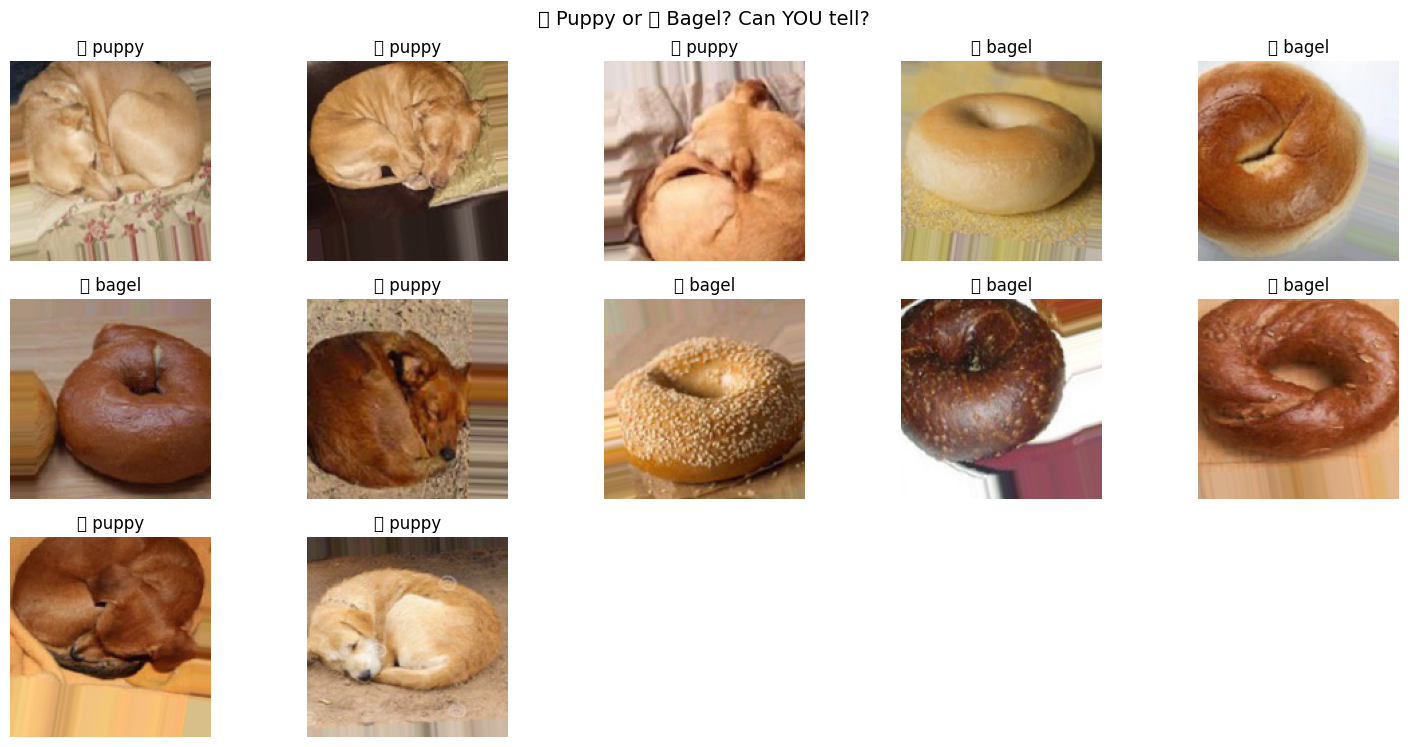

In [15]:
# ============================================================
# VISUALIZE SAMPLE IMAGES
#
# Let's see what our puppies and bagels look like!
# Can you tell which is which?
# ============================================================

def show_batch(generator, class_names, num=20):
    """Display a grid of images from the generator."""
    # Get one batch of images and labels
    images, labels = next(generator)

    # Create figure with subplots
    plt.figure(figsize=(15, 10))

    for i in range(min(num, len(images))):
        plt.subplot(4, 5, i + 1)  # 4 rows × 5 columns
        plt.imshow(images[i])      # Show the image

        # Add label with emoji
        label_idx = int(labels[i])
        emoji = '🐶' if class_names[label_idx] == 'puppy' else '🥯'
        plt.title(f"{emoji} {class_names[label_idx]}")
        plt.axis('off')  # Hide axes

    plt.suptitle("🐶 Puppy or 🥯 Bagel? Can YOU tell?", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display sample images
show_batch(train_generator, class_names)

---
## 5. Part 1: Build a Custom CNN from Scratch 🏗️

Now it's YOUR turn to build a CNN! You'll complete several sections yourself.

### Our CNN Architecture Plan:
```
Input (150×150×3)
    ↓
Conv2D(32 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(64 filters) → ReLU → MaxPooling2D
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Conv2D(128 filters) → ReLU → MaxPooling2D    ← YOU CODE THIS
    ↓
Flatten
    ↓
Dense(512) → ReLU → Dropout(0.5)             ← YOU CODE THIS
    ↓
Dense(1) → Sigmoid                            ← YOU CODE THIS
    ↓
Output (0 = bagel, 1 = puppy)
```

In [16]:
# ============================================================
# BUILD CNN - STEP 1: CREATE MODEL AND FIRST TWO BLOCKS
#
# We'll start with Sequential API and add the first two
# convolutional blocks (provided for you as example)
# ============================================================

# Create a Sequential model - layers are added in order
model_custom = models.Sequential([

    # ========== FIRST CONVOLUTIONAL BLOCK ==========
    # Conv2D: Creates 32 different 3x3 filters to detect features
    # - 32 = number of filters (feature detectors)
    # - (3,3) = filter size (3x3 pixels)
    # - activation='relu' = ReLU makes negative values zero
    # - input_shape = (height, width, channels) for RGB images
    layers.Conv2D(32, (3, 3), activation='relu',
                  input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # MaxPooling: Reduces image size by taking max in 2x2 windows
    # This makes the model focus on the strongest features
    layers.MaxPooling2D((2, 2)),

    # ========== SECOND CONVOLUTIONAL BLOCK ==========
    # More filters (64) to detect more complex patterns
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
])

print("✅ Created model with first two convolutional blocks!")
print("\n📐 Current model architecture:")
model_custom.summary()

✅ Created model with first two convolutional blocks!

📐 Current model architecture:


/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Third Convolutional Block

**Task:** Add a convolutional block with **128 filters**

**What to add:**
1. `Conv2D` layer with 128 filters, (3,3) kernel, ReLU activation
2. `MaxPooling2D` layer with (2,2) pool size

**Syntax help:**
```python
model_custom.add(layers.Conv2D(num_filters, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))
```

In [17]:
# ============================================================
# YOUR CODE HERE: ADD THE THIRD CONVOLUTIONAL BLOCK
#
# Instructions:
# 1. Add Conv2D with 128 filters, kernel (3,3), activation 'relu'
# 2. Add MaxPooling2D with pool size (2,2)
# ============================================================

# Third convolutional block - 128 filters
# HINT: model_custom.add(layers.Conv2D(???, (?, ?), activation='???'))
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))

# HINT: model_custom.add(layers.MaxPooling2D((?, ?)))
model_custom.add(layers.MaxPooling2D((2, 2)))

print("Third block added! Check the summary below:")
model_custom.summary()

Third block added! Check the summary below:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,248 (364.25 KB)

 Trainable params: 93,248 (364.25 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Fourth Convolutional Block

**Task:** Add another convolutional block with **128 filters** (same as third block)

In [18]:
# ============================================================
# YOUR CODE HERE: ADD THE FOURTH CONVOLUTIONAL BLOCK
#
# Same as the third block: Conv2D(128) + MaxPooling2D
# ============================================================

# Fourth convolutional block - 128 filters
model_custom.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_custom.add(layers.MaxPooling2D((2, 2)))

print("Fourth block added! You should now have 4 conv2d layers:")
model_custom.summary()

Fourth block added! You should now have 4 conv2d layers:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 240,832 (940.75 KB)

 Trainable params: 240,832 (940.75 KB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Add the Classification Layers

Now we need to add the "head" of our network that makes the final classification decision.

**What to add (in order):**
1. `Flatten()` - Converts 2D feature maps to 1D vector
2. `Dense(512, activation='relu')` - Fully connected layer with 512 neurons
3. `Dropout(0.5)` - Randomly turns off 50% of neurons (prevents overfitting)
4. `Dense(1, activation='sigmoid')` - Output: probability of being a puppy

**Syntax help:**
```python
model_custom.add(layers.Flatten())
model_custom.add(layers.Dense(units, activation='relu'))
model_custom.add(layers.Dropout(rate))  # rate is between 0 and 1
```

In [19]:
# ============================================================
# YOUR CODE HERE: ADD THE CLASSIFICATION LAYERS
#
# Add these 4 layers in order:
# 1. Flatten()
# 2. Dense(512, activation='relu')
# 3. Dropout(0.5)
# 4. Dense(1, activation='sigmoid')
# ============================================================

# Flatten - converts 2D to 1D
# HINT: model_custom.add(layers.Flatten())
model_custom.add(layers.Flatten())

# Dense layer with 512 neurons
# HINT: model_custom.add(layers.Dense(???, activation='???'))
model_custom.add(layers.Dense(512, activation='relu'))

# Dropout for regularization (50% = 0.5)
# HINT: model_custom.add(layers.Dropout(???))
model_custom.add(layers.Dropout(0.5))

# Output layer - 1 neuron with sigmoid for binary classification
# Sigmoid outputs a probability between 0 and 1
# HINT: model_custom.add(layers.Dense(???, activation='???'))
model_custom.add(layers.Dense(1, activation='sigmoid'))

print("📐 COMPLETE MODEL ARCHITECTURE:")
model_custom.summary()

📐 COMPLETE MODEL ARCHITECTURE:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### ✏️ YOUR TURN: Compile the Model

Before training, we must **compile** the model to configure:
- **Optimizer**: How to update weights (use `'adam'`)
- **Loss function**: What to minimize (use `'binary_crossentropy'` for binary classification)
- **Metrics**: What to track (use `['accuracy']`)

**Syntax:**
```python
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
```

In [20]:
# ============================================================
# YOUR CODE HERE: COMPILE THE MODEL
#
# Use:
# - optimizer: 'adam'
# - loss: 'binary_crossentropy'
# - metrics: ['accuracy']
# ============================================================

# HINT: model_custom.compile(optimizer='???', loss='???', metrics=['???'])
model_custom.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("✅ Model compiled and ready to train!")

✅ Model compiled and ready to train!


In [21]:
# ============================================================
# CALCULATE TRAINING STEPS
#
# steps_per_epoch = how many batches to process per epoch
# This is: total_samples ÷ batch_size
# ============================================================

import math
steps_per_epoch = math.ceil(train_generator.samples / BATCH_SIZE)
validation_steps = math.ceil(validation_generator.samples / BATCH_SIZE) if validation_generator else None

print(f"📊 Training setup:")
print(f"   Total training images: {train_generator.samples}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Steps per epoch: {steps_per_epoch}")
print(f"   Total epochs: {EPOCHS_CUSTOM}")

📊 Training setup:
   Total training images: 12
   Batch size: 32
   Steps per epoch: 1
   Total epochs: 15


In [22]:
# ============================================================
# SETUP CALLBACKS FOR SMARTER TRAINING
#
# Callbacks are functions that run during training:
# - EarlyStopping: Stop if no improvement (saves time!)
# - ModelCheckpoint: Save best model (important for Colab!)
# ============================================================

callbacks = [
    # EarlyStopping: Stop if validation loss doesn't improve
    keras.callbacks.EarlyStopping(
        monitor='val_loss',         # Watch this metric
        patience=5,                  # Wait 5 epochs for improvement
        restore_best_weights=True    # Go back to best weights
    ),

    # ModelCheckpoint: Save best model during training
    keras.callbacks.ModelCheckpoint(
        'best_custom_model.keras',   # Filename
        monitor='val_accuracy',       # Save when this improves
        save_best_only=True,          # Only keep the best
        verbose=1                     # Print when saving
    )
]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [23]:
# ============================================================
# TRAIN THE CUSTOM CNN
#
# This is where the magic happens!
# The model learns from the training data over multiple epochs.
# Watch the accuracy improve!
# ============================================================

print("\n🚀 Training the Puppy vs Bagel classifier...")
print("   This may take several minutes.\n")

history_custom = model_custom.fit(
    train_generator,                     # Training data
    steps_per_epoch=steps_per_epoch,     # Batches per epoch
    epochs=EPOCHS_CUSTOM,                # Number of epochs
    validation_data=validation_generator, # Validation data
    validation_steps=validation_steps,   # Validation batches
    callbacks=callbacks,                 # Our callbacks
    verbose=1                            # Show progress
)

print("\n✅ Training complete!")


🚀 Training the Puppy vs Bagel classifier...
   This may take several minutes.

Epoch 1/15


/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.6667 - loss: 0.6805
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_custom_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 789ms/step - accuracy: 0.6667 - loss: 0.6805 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 2/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3333 - loss: 0.7225
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.3333 - loss: 0.7225 - val_accuracy: 0.5000 - val_loss: 0.7232
Epoch 3/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5000 - loss: 0.7646
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5000 - loss: 0.7646 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 4/15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5833 - loss: 0.6647
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5833 - loss: 0.6647 - val_accura

/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/1848403022.py:30: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/1848403022.py:30: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


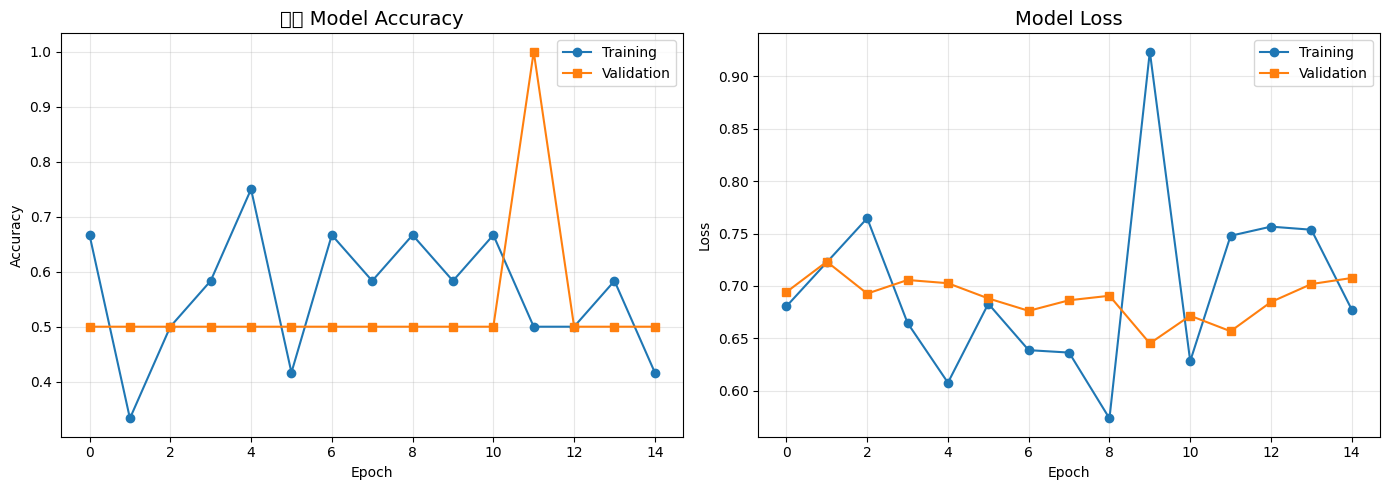


📊 How to read these plots:
   • Lines close together = Good generalization
   • Validation worse than training = Overfitting
   • Both lines plateau = Model has converged


In [24]:
# ============================================================
# VISUALIZE TRAINING HISTORY
#
# These plots help us understand how training went:
# - Accuracy plot: Should increase over time
# - Loss plot: Should decrease over time
# - Gap between train/val lines indicates overfitting
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax1.plot(history_custom.history['accuracy'], label='Training', marker='o')
ax1.plot(history_custom.history['val_accuracy'], label='Validation', marker='s')
ax1.set_title('🐶🥯 Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot Loss
ax2.plot(history_custom.history['loss'], label='Training', marker='o')
ax2.plot(history_custom.history['val_loss'], label='Validation', marker='s')
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 How to read these plots:")
print("   • Lines close together = Good generalization")
print("   • Validation worse than training = Overfitting")
print("   • Both lines plateau = Model has converged")

In [25]:
# ============================================================
# EVALUATE CUSTOM CNN
#
# Scope is controlled by EVAL_SCOPE:
# - 'test' -> holdout test split
# - 'all'  -> train+val+test merged
# ============================================================

if eval_generator_custom is not None:
    eval_generator_custom.reset()
    test_loss, test_acc = model_custom.evaluate(eval_generator_custom, verbose=0)

    print(f"\n📊 Custom CNN Results ({eval_scope_custom}):")
    print(f"   Samples: {eval_generator_custom.samples}")
    print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"   Loss: {test_loss:.4f}")
else:
    print("⚠️ No evaluation generator available for custom CNN.")



📊 Custom CNN Results (test split):
   Samples: 2
   Accuracy: 0.5000 (50.00%)
   Loss: 0.8205


---
## 6. Part 2: Transfer Learning with Pre-trained Models

Transfer learning uses models already trained on millions of images. We just add our own classification layers on top! This usually gives better results with less training time.

### ⚠️ Colab Free Tier Tips:
If you get **"Out of Memory"** errors:
1. Set `USE_MOBILENET = True` below (smaller model)
2. Restart runtime: Runtime → Restart runtime

In [26]:
# ============================================================
# CHOOSE YOUR PRE-TRAINED MODEL
#
# MobileNetV2: Smaller, faster (good for Colab Free)
# ResNet50: Larger, more powerful
# ============================================================

# Change to True if you're running out of memory!
USE_MOBILENET = False

if USE_MOBILENET:
    IMG_SIZE_TRANSFER = 128
    print("📱 Using MobileNetV2 (lightweight, great for Colab Free)")
else:
    IMG_SIZE_TRANSFER = 224
    print("🔬 Using ResNet50 (powerful, needs more memory)")

🔬 Using ResNet50 (powerful, needs more memory)


In [27]:
# ============================================================
# CREATE DATA GENERATORS FOR TRANSFER LEARNING
# ============================================================

train_gen_tf = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

if valid_dir:
    val_gen_tf = test_datagen.flow_from_directory(
        valid_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
else:
    val_gen_tf = None

if test_dir:
    test_gen_tf = test_datagen.flow_from_directory(
        test_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )
else:
    test_gen_tf = val_gen_tf

all_gen_tf = None
eval_gen_tf = test_gen_tf
eval_scope_tf = "test split"

if EVAL_SCOPE.lower() == "all":
    if "build_all_eval_dir" not in globals():
        raise RuntimeError("build_all_eval_dir is missing")

    if "all_eval_dir" not in globals() or all_eval_dir is None or not os.path.isdir(all_eval_dir):
        all_eval_dir, _ = build_all_eval_dir(DATASET_PATH)

    all_gen_tf = test_datagen.flow_from_directory(
        all_eval_dir,
        target_size=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    eval_gen_tf = all_gen_tf
    eval_scope_tf = "all images (train+val+test)"

print(f"✅ Created generators for {IMG_SIZE_TRANSFER}x{IMG_SIZE_TRANSFER} images")
print("Train:", train_gen_tf.samples)
print("Val:", val_gen_tf.samples if val_gen_tf else 0)
print("Test:", test_gen_tf.samples if test_gen_tf else 0)
print("Transfer evaluation scope:", eval_scope_tf, "samples:", eval_gen_tf.samples if eval_gen_tf else 0)


Found 12 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
✅ Created generators for 224x224 images
Train: 12
Val: 2
Test: 2
Transfer evaluation scope: test split samples: 2


In [28]:
# ============================================================
# LOAD THE PRE-TRAINED MODEL
#
# Key parameters:
# - weights='imagenet': Use weights trained on ImageNet
# - include_top=False: Remove original classification layers
# - trainable=False: Freeze weights (don't update during training)
# ============================================================

if USE_MOBILENET:
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "MobileNetV2"
else:
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER, 3)
    )
    model_name = "ResNet50"

# Freeze the base model - we won't train these layers
base_model.trainable = False

print(f"✅ Loaded {model_name}")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   All layers frozen (won't be trained)")

✅ Loaded ResNet50
   Total layers: 175
   All layers frozen (won't be trained)


In [29]:
# ============================================================
# BUILD TRANSFER LEARNING MODEL
#
# We add our own classification layers on top:
# - GlobalAveragePooling2D: Reduces feature maps to vectors
# - Dense: Our classification layers
# ============================================================

model_transfer = models.Sequential([
    # Pre-trained base (frozen)
    base_model,

    # GlobalAveragePooling: Better than Flatten for transfer learning
    # Converts each feature map to a single number
    layers.GlobalAveragePooling2D(),

    # Our custom classification layers
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_transfer.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f"\n📐 {model_name} Transfer Learning Model:")
model_transfer.summary()


📐 ResNet50 Transfer Learning Model:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [30]:
# ============================================================
# TRAIN TRANSFER LEARNING MODEL
#
# Training is MUCH faster because we only train a few layers!
# The pre-trained layers already know how to detect features.
# ============================================================

steps_tf = math.ceil(train_gen_tf.samples / BATCH_SIZE)
val_steps_tf = math.ceil(val_gen_tf.samples / BATCH_SIZE) if valid_dir else None

callbacks_tf = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint('best_transfer_model.keras', monitor='val_accuracy',
                                    save_best_only=True, verbose=1)
]

print(f"\n🚀 Training {model_name} with Transfer Learning...\n")

history_transfer = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=EPOCHS_TRANSFER,
    validation_data=val_gen_tf if valid_dir else None,
    validation_steps=val_steps_tf,
    callbacks=callbacks_tf,
    verbose=1
)

print("\n✅ Transfer learning complete!")


🚀 Training ResNet50 with Transfer Learning...

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4167 - loss: 1.0908
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to best_transfer_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 1.0908 - val_accuracy: 0.5000 - val_loss: 0.7472
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.5833 - loss: 0.6408
Epoch 2: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.5833 - loss: 0.6408 - val_accuracy: 0.5000 - val_loss: 0.8019
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.3333 - loss: 0.7321
Epoch 3: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.3333 - loss: 0.7321 - val_accuracy: 0.5000 - val_loss: 0.7578
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.5833 - loss: 0.7733
Epoch 4: val_accuracy did not improve from 0.50000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 3

In [31]:
# ============================================================
# EVALUATE TRANSFER LEARNING MODEL
# ============================================================

if eval_gen_tf is not None:
    eval_gen_tf.reset()
    test_loss_tf, test_acc_tf = model_transfer.evaluate(eval_gen_tf, verbose=0)

    print(f"\n📊 {model_name} Transfer Learning Results ({eval_scope_tf}):")
    print(f"   Samples: {eval_gen_tf.samples}")
    print(f"   Accuracy: {test_acc_tf:.4f} ({test_acc_tf*100:.2f}%)")
    print(f"   Loss: {test_loss_tf:.4f}")
else:
    print("⚠️ No evaluation generator available for transfer learning.")



📊 ResNet50 Transfer Learning Results (test split):
   Samples: 2
   Accuracy: 0.5000 (50.00%)
   Loss: 0.6992


---
## 7. Compare Results

In [32]:
# ============================================================
# CREATE COMPARISON TABLE
# ============================================================

import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Custom CNN', f'Transfer ({model_name})'],
    'Eval Scope': [eval_scope_custom, eval_scope_tf],
    'Eval Accuracy': [f"{test_acc*100:.2f}%", f"{test_acc_tf*100:.2f}%"],
    'Eval Loss': [f"{test_loss:.4f}", f"{test_loss_tf:.4f}"],
    'Epochs': [len(history_custom.history['loss']), len(history_transfer.history['loss'])]
})

print("\n" + "="*72)
print("🏆 MODEL COMPARISON: Puppy vs Bagel")
print("="*72)
print(comparison.to_string(index=False))
print("="*72)


🏆 MODEL COMPARISON: Puppy vs Bagel
              Model Eval Scope Eval Accuracy Eval Loss  Epochs
         Custom CNN test split        50.00%    0.8205      15
Transfer (ResNet50) test split        50.00%    0.6992      10


---
## 8. Visualize Predictions

/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/222193067.py:32: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/222193067.py:32: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p8/f7jg3zj519l4lhh5dn9dbqtm0000gn/T/ipykernel_33684/222193067.py:32: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jirimusil/Library/Pytho

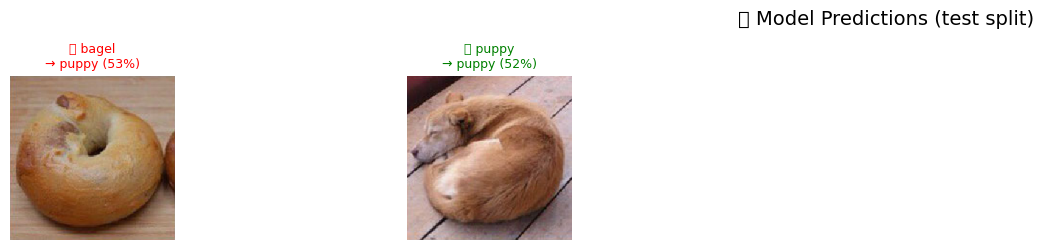

In [33]:
# ============================================================
# VISUALIZE MODEL PREDICTIONS
#
# Green title = Correct prediction
# Red title = Wrong prediction
# ============================================================

if eval_gen_tf is not None:
    eval_gen_tf.reset()
    images, labels = next(eval_gen_tf)
    preds = model_transfer.predict(images[:20], verbose=0)

    plt.figure(figsize=(20, 8))
    for i in range(min(20, len(images))):
        plt.subplot(4, 5, i + 1)
        plt.imshow(images[i])

        # Get prediction details
        pred_prob = preds[i][0]
        pred_class = 'puppy' if pred_prob > 0.5 else 'bagel'
        true_class = class_names[int(labels[i])]
        confidence = pred_prob if pred_prob > 0.5 else 1 - pred_prob

        # Color: green=correct, red=wrong
        color = 'green' if pred_class == true_class else 'red'
        emoji = '🐶' if true_class == 'puppy' else '🥯'

        plt.title(f"{emoji} {true_class}\n→ {pred_class} ({confidence:.0%})", color=color, fontsize=9)
        plt.axis('off')

    plt.suptitle(f'🔍 Model Predictions ({eval_scope_tf})', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No evaluation generator available for prediction visualization.")


---
## 9. Confusion Matrix

/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/seaborn/utils.py:61: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/seaborn/utils.py:61: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jirimusil/Library/Python/3.9/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 129391 (\N{BAGEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


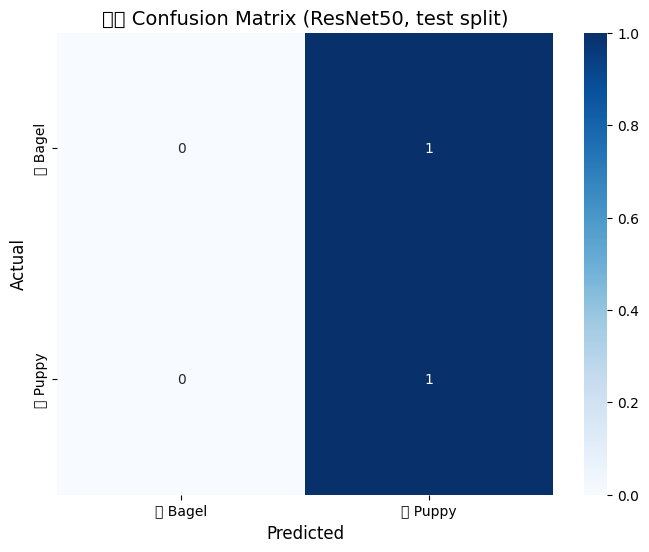


📋 Classification Report:
              precision    recall  f1-score   support

       Bagel       0.00      0.00      0.00         1
       Puppy       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



In [34]:
# ============================================================
# GENERATE CONFUSION MATRIX
#
# Shows where the model gets confused:
# - Diagonal = correct predictions
# - Off-diagonal = errors
# ============================================================

if eval_gen_tf is not None:
    eval_gen_tf.reset()
    y_pred = (model_transfer.predict(eval_gen_tf, verbose=0) > 0.5).astype(int).flatten()
    y_true = eval_gen_tf.classes

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['🥯 Bagel', '🐶 Puppy'],
        yticklabels=['🥯 Bagel', '🐶 Puppy']
    )
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.title(f'🐶🥯 Confusion Matrix ({model_name}, {eval_scope_tf})', fontsize=14)
    plt.show()

    print("\n📋 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Bagel', 'Puppy'], zero_division=0))
else:
    print("⚠️ No evaluation generator available for confusion matrix.")


---
## 10. Reflective Questions

### Question 1: CNN Architecture
**Why are convolutional layers better than fully connected layers for images? How do they help distinguish puppies from bagels?**

My answer: Convolutional layers are better for images because they look at small nearby parts of a picture and reuse the same pattern checker across the whole image. This keeps the image layout meaningful and uses fewer numbers to train than fully connected layers. For puppies vs bagels, it helps the model spot things like fur, eyes, and ears instead of only seeing a round shape.

---

### Question 2: Data Augmentation
**Why did we use data augmentation for training? How does rotation, flipping, and zooming help the model learn?**

My answer: We used data augmentation because the training set is very small, so we needed more variety. Rotation, flipping, and zooming teach the model that the object is still the same even when angle, position, or size changes. This helps it learn the real class patterns instead of memorizing a few photos.

---

### Question 3: Transfer Learning
**Why does transfer learning often achieve better results than training from scratch, especially with small datasets?**

My answer: Transfer learning usually works better on small datasets because the model already learned useful image patterns from a very large dataset. We only need to train the final part for our classes, which needs less data. Training from scratch must learn everything from zero, so it often struggles with limited images. In this lab, transfer learning still stayed at 50% test accuracy because we only had 12 training images.

---

### Question 4: Model Comparison
**Which model performed better in your experiment? What factors explain the difference?**

My answer: Neither model clearly performed better here since both were around 50% test accuracy. The main issue was the tiny dataset, which is too small for dependable learning and testing. With more images, the transfer learning model would likely have a clearer advantage.

---

### Question 5: Challenging Cases
**Looking at the predictions, what visual features might make puppies look like bagels (or vice versa)?**

My answer: Puppies and bagels can look alike because both can appear round and tan, especially in warm lighting. Fur can sometimes look similar to crust texture in low detail images, and plain backgrounds can add confusion. More varied training images would help the model learn stronger clues like eyes and nose versus a smooth ring with a center hole.


---
## 11. Student Challenge: Fine-tune the Model

**Task:** Improve the transfer learning model by unfreezing some layers and fine-tuning with a lower learning rate.

In [35]:
# ============================================================
# YOUR CODE HERE: FINE-TUNE THE TRANSFER LEARNING MODEL
# ============================================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_ft = model_transfer.fit(
    train_gen_tf,
    steps_per_epoch=steps_tf,
    epochs=5,
    validation_data=val_gen_tf,
    validation_steps=val_steps_tf,
    verbose=1
)

before_acc = test_acc_tf if "test_acc_tf" in globals() else None
before_loss = test_loss_tf if "test_loss_tf" in globals() else None

if eval_gen_tf is not None:
    eval_gen_tf.reset()
    ft_loss, ft_acc = model_transfer.evaluate(eval_gen_tf, verbose=0)

    ft_acc_tf = ft_acc
    ft_loss_tf = ft_loss

    if before_acc is not None and before_loss is not None:
        print("Before fine tuning accuracy:", f"{before_acc*100:.2f}%")
        print("After fine tuning accuracy:", f"{ft_acc*100:.2f}%")
        print("Before fine tuning loss:", f"{before_loss:.4f}")
        print("After fine tuning loss:", f"{ft_loss:.4f}")
    else:
        print("Fine tuned accuracy:", f"{ft_acc*100:.2f}%")
        print("Fine tuned loss:", f"{ft_loss:.4f}")
else:
    print("No evaluation generator available")


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.4167 - loss: 0.7661 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step - accuracy: 0.4167 - loss: 0.7164 - val_accuracy: 0.5000 - val_loss: 0.6918
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 597ms/step - accuracy: 0.5833 - loss: 0.6060 - val_accuracy: 0.5000 - val_loss: 0.6912
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step - accuracy: 0.6667 - loss: 0.7633 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step - accuracy: 0.5000 - loss: 0.5848 - val_accuracy: 0.5000 - val_loss: 0.6927
Before fine tuning accuracy: 50.00%
After fine tuning accuracy: 50.00%
Before fine tuning loss: 0.6992
After fine tuning loss: 0.6984


**Challenge Question:** Did fine-tuning improve performance? Why or why not?

My answer: No, fine-tuning did not improve performance in this run. Test accuracy stayed at 50.00% before and after fine-tuning, so the model did not classify better. Test loss changed from 0.6992 to 0.6984, which is a very small difference. The dataset was extremely small with only 12 training images and 2 test images, so results are unstable and hard to trust. Validation loss also stayed almost flat during fine-tuning, which suggests the model was not learning much new from these extra training steps. To improve results, we should collect many more labeled images, keep classes balanced, and evaluate on a larger test set.


---
## 12. Save Your Model

In [36]:
# ============================================================
# SAVE THE TRAINED MODEL
#
# Important for Colab - download before your session ends!
# ============================================================

model_transfer.save('puppy_bagel_classifier.keras')
print("✅ Model saved as 'puppy_bagel_classifier.keras'")

# Download in Colab
if IN_COLAB:
    from google.colab import files
    files.download('puppy_bagel_classifier.keras')
    print("📥 Model downloaded to your computer!")

✅ Model saved as 'puppy_bagel_classifier.keras'


---
## Submission Checklist

**Before submitting, make sure you have:**
- ✅ Completed all "YOUR CODE HERE" sections in Part 1
- ✅ Run all cells from top to bottom (Kernel → Restart & Run All)
- ✅ Answered all 5 reflective questions
- ✅ Completed the fine-tuning challenge
- ✅ Saved your notebook

**Filename:** `Module_03_Lab_YourName.ipynb`

---
**Congratulations!** 🎉 You built a CNN that can tell puppies from bagels! 🐶🥯

---
## Resources

**Dataset:**
- Puppy or Bagel: https://www.kaggle.com/datasets/returnofsputnik/puppy-or-bagel

**Alternative Fun Datasets:**
- Muffin vs Chihuahua: https://www.kaggle.com/datasets/samuelcortinhas/muffin-vs-chihuahua-image-classification
- Corgi Butt vs Bread: https://github.com/Kawaeee/butt_or_bread

**Original Meme Creator:** Karen Zack (@teenybiscuit)